# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Marana, Kyle
- _Student No._: 2024-14996
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_


---
## Section 1: Report

![A](fig1.png)
**Figure 1. Voltage Distribution for N = 10,000**

The figure plots voltage against node number for a resistor ladder chain of 10,000 nodes. The relationship is a straight line, decreasing linearly from 5 V at node 0 down to 0 V at node 10,000. This confirms the physical expectation for this resistor network since every internal node satisfies the same Kirchhoff current-law relation. No curvature or discontinuities appeared, indicating that banded.py produced a numerically stable, physically consistent result across all 10,000 

The banded matrix system was built directly from the Kirchhoff current law at each internal node — the net current into any junction must be zero — combined with Ohm's law across each resistor. For an internal node $i$, this gives

$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0$$

since each node connects to its two nearest and two next-nearest neighbors through equal resistors $R$. The two boundary nodes only have one "outer" neighbor, so their diagonal coefficient drops from 4 to 3, and the source voltage $V_+ = 5$V appears on the right-hand side of the first two equations. Stacking all $N$ equations gives the pentadiagonal system $A\vec{v} = \vec{w}$, with 4 (or 3 at the ends) on the main diagonal, $-1$ on the two nearest off-diagonals in each direction, and $\vec{w}$ zero except $w_1 = w_2 = 5$.

To solve this, $N=6$ used `np.linalg.solve(A, w)`, which factorizes the dense matrix via LU decomposition (Gaussian elimination with partial pivoting) then applies forward/backward substitution — accurate but $O(N^3)$, so a 10,000×10,000 dense matrix would be far too slow and memory-heavy. For $N=10{,}000$, I instead used `banded()` from Mark Newman's `banded.py`, storing only the nonzero diagonals in a compact array and restricting the elimination to the band itself. This drops the cost to roughly $O(N)$, making the large-N case tractable.





---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [22]:
N=6

#creating Matrix A
A = np.zeros((N,N))

for i in range(N):

    #main diagonal
    if i == 0 or i == N-1:
        A[i,i] = 3
    else:
        A[i,i] = 4

    #first off diagonal
    if i-1 >= 0:
        A[i, i-1] = -1

    if i+1 < N:
        A[i, i+1] = -1

    #second off diagonal
    if i-2 >= 0:
        A[i, i-2] = -1

    if i+2 < N:
        A[i, i+2] = -1

#creating matrix w

w = np.zeros(N)
w[0] = 5
w[1] = 5

#computing for Av = w

V = np.linalg.solve(A,w)

print("A =")
print(A)

print("\nw =")
print(w)

print("\nVoltages:")
for i in range(N):
    print(f"V{i+1} = {V[i]:.6f} V")
    

A =
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]

w =
[5. 5. 0. 0. 0. 0.]

Voltages:
V1 = 3.725490 V
V2 = 3.431373 V
V3 = 2.745098 V
V4 = 2.254902 V
V5 = 1.568627 V
V6 = 1.274510 V


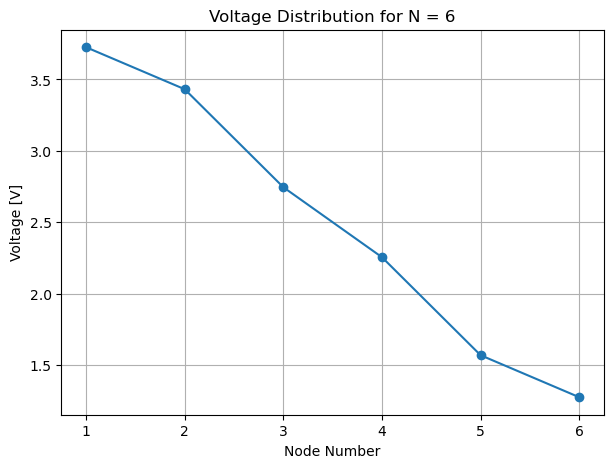

In [24]:
# graphing N=6
nodes6 = np.arange(1, N+1)

plt.figure(figsize=(7,5))
plt.plot(nodes6, V, marker='o')

plt.xlabel("Node Number")
plt.ylabel("Voltage [V]")
plt.title(f"Voltage Distribution for N = {N}")
plt.grid()
plt.savefig('fig_N6.png', format='png', dpi=300)

plt.show()


In [25]:
N=10000

#constructs the banded matrix
# 5 = 2 upper/lower diagonal + main diagonal
bd_A = np.zeros((5,N))

#main diagonal
bd_A[2, :] = 4
bd_A[2, 0] = 3
bd_A[2, N-1] = 3

#first upper diagonal
bd_A[1, 1:] = -1

#second upper diagonal
bd_A[0, 2:] = -1

#first lower diagonal
bd_A[3, :-1] = -1

#second lower diagonal
bd_A[4, :-2] = -1

#righthand side vector
bd_w = np.zeros(N)

bd_w[0] = 5
bd_w[1] = 5

#computing for AV = w
bd_V = bd.banded(bd_A, bd_w, 2, 2)

print("V1 =", bd_V[0])
print("V2 =", bd_V[1])
print("V3 =", bd_V[2])

print("VN-2 =", bd_V[N-3])
print("VN-1 =", bd_V[N-2])
print("VN =", bd_V[N-1])

print("Minimum Voltage =", bd_V.min())
print("Maximum Voltage =", bd_V.max())


V1 = 4.998882277727716
V2 = 4.998618419291493
V3 = 4.9980284138916575
VN-2 = 0.001971586108334918
VN-1 = 0.0013815807085025764
VN = 0.0011177222722791647
Minimum Voltage = 0.0011177222722791647
Maximum Voltage = 4.998882277727716


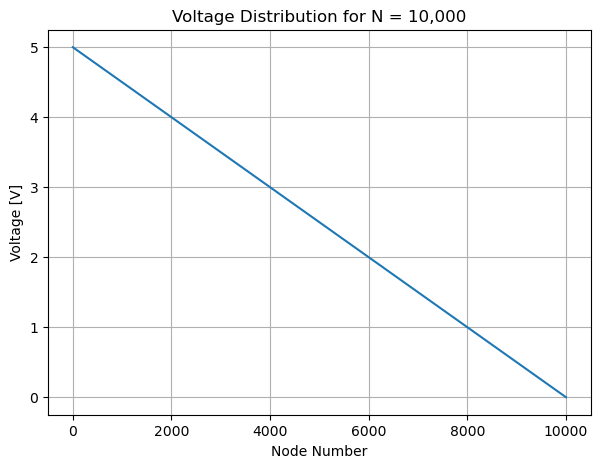

In [26]:
#graphing N=10000

nodes = np.arange(1, N+1)

plt.figure(figsize=(7,5))
plt.plot(nodes, bd_V)

plt.xlabel("Node Number")
plt.ylabel("Voltage [V]")
plt.title("Voltage Distribution for N = 10,000")
plt.grid()
plt.savefig('fig1.png', format='png', dpi=300)

plt.show()


#### Problem 1 code summary

The code was written this way because a full N×N matrix (10,000 × 10,000) would need a lot memory and require solving a general dense linear system, which is takes up lots of memory and slow. Since the resistor-chain matrix is banded, it stored it in the compact 5×N banded format and used a dedicated banded solver (banded.py) instead of np.linalg.solve. This exploits the matrix's short structure to solve the system in roughly linear time and memory, letting me scale to N = 10,000 nodes without crashing.

---


## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])